# Master Figure: Token Length Distributions

Comprehensive comparison of token length distributions across:
- Training progression (1, 5, 22 epochs)
- Datasets (PI1M polymer vs. MOSES molecular)
- H-Net vs. SmilesPE benchmark

## Figure Layout

**Panel A (PI1M):** 4 distributions
- Concatenated 1 epoch (light blue)
- Concatenated 5 epochs (medium blue)
- Concatenated 22 epochs (dark blue)
- SmilesPE (red)

**Panel B (MOSES):** 2 distributions
- Concatenated 5 epochs (blue)
- SmilesPE (red)


In [1]:
import sys
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setup plotting style
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (18, 10)

# Paths
project_root = Path.cwd().parent.parent
hnet_results_dir = project_root / 'analysis' / 'data' / 'hnet_results'
smilesPE_results_dir = project_root / 'analysis' / 'data' / 'smilesPE_results'
figures_dir = project_root / 'analysis' / 'figures'
figures_dir.mkdir(exist_ok=True)

print("✓ Imports complete")


✓ Imports complete


In [2]:
def load_token_lengths(results_file):
    """Load tokenization results and extract token lengths."""
    with open(results_file, 'rb') as f:
        results = pickle.load(f)
    
    token_lengths = []
    for result in results:
        if 'tokens' in result:
            for token in result['tokens']:
                token_lengths.append(len(token))
    
    return np.array(token_lengths)

print("Loading H-Net results...")

# PI1M H-Net models (concatenated progression: 1, 5, 22 epochs)
pi1m_1epoch_lengths = load_token_lengths(hnet_results_dir / 'PI1M_concat_1epoch_tokenization.pkl')
pi1m_5epoch_lengths = load_token_lengths(hnet_results_dir / 'PI1M_concat_5epoch_tokenization.pkl')
pi1m_22epoch_lengths = load_token_lengths(hnet_results_dir / 'PI1M_concat_22epoch_tokenization.pkl')

# MOSES H-Net model (5 epochs)
moses_5epoch_lengths = load_token_lengths(hnet_results_dir / 'MOSES_concat_5epoch_tokenization.pkl')

print("Loading SmilesPE results...")

# SmilesPE benchmarks
pi1m_spe_lengths = load_token_lengths(smilesPE_results_dir / 'SmilesPE_PI1M_tokenization.pkl')
moses_spe_lengths = load_token_lengths(smilesPE_results_dir / 'SmilesPE_MOSES_tokenization.pkl')

print(f"\n✓ Data loaded:")
print(f"  PI1M 1 epoch:  {len(pi1m_1epoch_lengths):,} tokens (mean: {np.mean(pi1m_1epoch_lengths):.2f})")
print(f"  PI1M 5 epochs: {len(pi1m_5epoch_lengths):,} tokens (mean: {np.mean(pi1m_5epoch_lengths):.2f})")
print(f"  PI1M 22 epochs: {len(pi1m_22epoch_lengths):,} tokens (mean: {np.mean(pi1m_22epoch_lengths):.2f})")
print(f"  PI1M SmilesPE: {len(pi1m_spe_lengths):,} tokens (mean: {np.mean(pi1m_spe_lengths):.2f})")
print(f"  MOSES 5 epochs: {len(moses_5epoch_lengths):,} tokens (mean: {np.mean(moses_5epoch_lengths):.2f})")
print(f"  MOSES SmilesPE: {len(moses_spe_lengths):,} tokens (mean: {np.mean(moses_spe_lengths):.2f})")


Loading H-Net results...
Loading SmilesPE results...

✓ Data loaded:
  PI1M 1 epoch:  216,277 tokens (mean: 2.20)
  PI1M 5 epochs: 182,298 tokens (mean: 2.62)
  PI1M 22 epochs: 165,928 tokens (mean: 2.87)
  PI1M SmilesPE: 113,497 tokens (mean: 4.20)
  MOSES 5 epochs: 172,964 tokens (mean: 2.01)
  MOSES SmilesPE: 58,589 tokens (mean: 5.94)



✓ Figure saved to: /home/ec2-user/hnet_smiles/analysis/figures/master_token_length_distributions.png
  File size: 301.8 KB


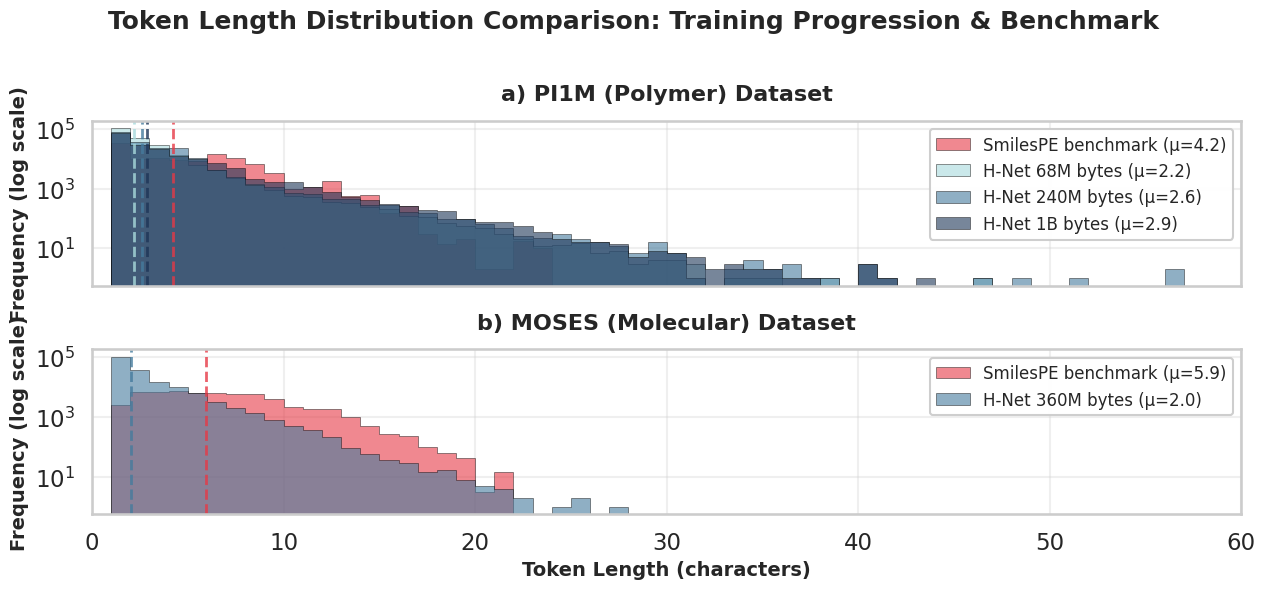

In [17]:
# Create figure with two panels sharing x-axis
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Color schemes
blues = ['#a8dadc', '#457b9d', '#1d3557']  # Light, medium, dark blue
red = '#e63946'

# Common histogram parameters
bins = np.arange(1, 101, 1)  # 1 to 20 characters
alpha = 0.6
linewidth = 2
histtype='stepfilled'

# ============================================================================
# PANEL A: PI1M (Polymer) Dataset
# ============================================================================
ax = axes[0]

# Plot histograms with filled distributions
ax.hist(pi1m_spe_lengths, bins=bins, histtype=histtype, alpha=alpha, color=red, 
        label=f'SmilesPE benchmark (μ={np.mean(pi1m_spe_lengths):.1f})', 
        edgecolor='black', linewidth=0.5,)

ax.hist(pi1m_1epoch_lengths, bins=bins, histtype=histtype, alpha=alpha, color=blues[0], 
        label=f'H-Net 68M bytes (μ={np.mean(pi1m_1epoch_lengths):.1f})', 
        edgecolor='black', linewidth=0.5)

ax.hist(pi1m_5epoch_lengths, bins=bins, histtype=histtype, alpha=alpha, color=blues[1], 
        label=f'H-Net 240M bytes (μ={np.mean(pi1m_5epoch_lengths):.1f})', 
        edgecolor='black', linewidth=0.5)

ax.hist(pi1m_22epoch_lengths, bins=bins,histtype=histtype, alpha=alpha, color=blues[2], 
        label=f'H-Net 1B bytes (μ={np.mean(pi1m_22epoch_lengths):.1f})', 
        edgecolor='black', linewidth=0.5)



# Add dashed lines for means
ymin, ymax = ax.get_ylim()
ax.axvline(np.mean(pi1m_1epoch_lengths), color=blues[0], linestyle='--', linewidth=linewidth, alpha=0.8)
ax.axvline(np.mean(pi1m_5epoch_lengths), color=blues[1], linestyle='--', linewidth=linewidth, alpha=0.8)
ax.axvline(np.mean(pi1m_22epoch_lengths), color=blues[2], linestyle='--', linewidth=linewidth, alpha=0.8)
ax.axvline(np.mean(pi1m_spe_lengths), color=red, linestyle='--', linewidth=linewidth, alpha=0.8)

# Set log scale on y-axis
ax.set_yscale('log')

# Labels and title
ax.set_ylabel('Frequency (log scale)', fontsize=14, fontweight='bold')
ax.set_title('a) PI1M (Polymer) Dataset', 
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3)

# # Add text annotation
# ax.text(0.02, 0.98, 'Training progression:\n1 → 5 → 22 epochs', 
#         transform=ax.transAxes, fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# PANEL B: MOSES (Molecular) Dataset
# ============================================================================
ax = axes[1]
ax.hist(moses_spe_lengths, bins=bins, histtype=histtype,alpha=alpha, color=red, 
        label=f'SmilesPE benchmark (μ={np.mean(moses_spe_lengths):.1f})', 
        edgecolor='black', linewidth=0.5)

# Plot histograms with filled distributions
ax.hist(moses_5epoch_lengths, bins=bins, histtype=histtype,alpha=alpha, color=blues[1], 
        label=f'H-Net 360M bytes (μ={np.mean(moses_5epoch_lengths):.1f})', 
        edgecolor='black', linewidth=0.5)



# Add dashed lines for means
ymin, ymax = ax.get_ylim()
ax.axvline(np.mean(moses_5epoch_lengths), color=blues[1], linestyle='--', linewidth=linewidth, alpha=0.8)
ax.axvline(np.mean(moses_spe_lengths), color=red, linestyle='--', linewidth=linewidth, alpha=0.8)

# Set log scale on y-axis
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Token Length (characters)', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency (log scale)', fontsize=14, fontweight='bold')
ax.set_title('b) MOSES (Molecular) Dataset', 
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3)

# Shared x-axis limits
ax.set_xlim(0, 60)

# Overall title
fig.suptitle('Token Length Distribution Comparison: Training Progression & Benchmark', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()

# Save figure
output_path = figures_dir / 'master_token_length_distributions.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved to: {output_path}")
print(f"  File size: {output_path.stat().st_size / 1024:.1f} KB")

plt.show()

## Summary Statistics

Detailed comparison of token length statistics across all models.


In [4]:
import pandas as pd

# Create summary table
summary_data = [
    {
        'Dataset': 'PI1M',
        'Model': 'H-Net 1 epoch',
        'Total Tokens': len(pi1m_1epoch_lengths),
        'Mean Length': np.mean(pi1m_1epoch_lengths),
        'Median Length': np.median(pi1m_1epoch_lengths),
        'Std Dev': np.std(pi1m_1epoch_lengths),
        'Min': np.min(pi1m_1epoch_lengths),
        'Max': np.max(pi1m_1epoch_lengths),
    },
    {
        'Dataset': 'PI1M',
        'Model': 'H-Net 5 epochs',
        'Total Tokens': len(pi1m_5epoch_lengths),
        'Mean Length': np.mean(pi1m_5epoch_lengths),
        'Median Length': np.median(pi1m_5epoch_lengths),
        'Std Dev': np.std(pi1m_5epoch_lengths),
        'Min': np.min(pi1m_5epoch_lengths),
        'Max': np.max(pi1m_5epoch_lengths),
    },
    {
        'Dataset': 'PI1M',
        'Model': 'H-Net 22 epochs',
        'Total Tokens': len(pi1m_22epoch_lengths),
        'Mean Length': np.mean(pi1m_22epoch_lengths),
        'Median Length': np.median(pi1m_22epoch_lengths),
        'Std Dev': np.std(pi1m_22epoch_lengths),
        'Min': np.min(pi1m_22epoch_lengths),
        'Max': np.max(pi1m_22epoch_lengths),
    },
    {
        'Dataset': 'PI1M',
        'Model': 'SmilesPE',
        'Total Tokens': len(pi1m_spe_lengths),
        'Mean Length': np.mean(pi1m_spe_lengths),
        'Median Length': np.median(pi1m_spe_lengths),
        'Std Dev': np.std(pi1m_spe_lengths),
        'Min': np.min(pi1m_spe_lengths),
        'Max': np.max(pi1m_spe_lengths),
    },
    {
        'Dataset': 'MOSES',
        'Model': 'H-Net 5 epochs',
        'Total Tokens': len(moses_5epoch_lengths),
        'Mean Length': np.mean(moses_5epoch_lengths),
        'Median Length': np.median(moses_5epoch_lengths),
        'Std Dev': np.std(moses_5epoch_lengths),
        'Min': np.min(moses_5epoch_lengths),
        'Max': np.max(moses_5epoch_lengths),
    },
    {
        'Dataset': 'MOSES',
        'Model': 'SmilesPE',
        'Total Tokens': len(moses_spe_lengths),
        'Mean Length': np.mean(moses_spe_lengths),
        'Median Length': np.median(moses_spe_lengths),
        'Std Dev': np.std(moses_spe_lengths),
        'Min': np.min(moses_spe_lengths),
        'Max': np.max(moses_spe_lengths),
    },
]

df_summary = pd.DataFrame(summary_data)

# Format numeric columns
df_summary['Total Tokens'] = df_summary['Total Tokens'].apply(lambda x: f"{x:,}")
df_summary['Mean Length'] = df_summary['Mean Length'].apply(lambda x: f"{x:.2f}")
df_summary['Median Length'] = df_summary['Median Length'].apply(lambda x: f"{x:.2f}")
df_summary['Std Dev'] = df_summary['Std Dev'].apply(lambda x: f"{x:.2f}")

print("\n" + "="*80)
print("TOKEN LENGTH STATISTICS SUMMARY")
print("="*80)
print(df_summary.to_string(index=False))
print("="*80)

# Save summary table
csv_path = project_root / 'analysis' / 'data' / 'master_token_length_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\n✓ Summary table saved to: {csv_path}")



TOKEN LENGTH STATISTICS SUMMARY
Dataset           Model Total Tokens Mean Length Median Length Std Dev  Min  Max
   PI1M   H-Net 1 epoch      216,277        2.20          2.00    1.97    1   46
   PI1M  H-Net 5 epochs      182,298        2.62          2.00    2.36    1   71
   PI1M H-Net 22 epochs      165,928        2.87          2.00    2.79    1   43
   PI1M        SmilesPE      113,497        4.20          4.00    3.10    1   23
  MOSES  H-Net 5 epochs      172,964        2.01          1.00    1.73    1   27
  MOSES        SmilesPE       58,589        5.94          6.00    3.27    1   21

✓ Summary table saved to: /home/ec2-user/hnet_smiles/analysis/data/master_token_length_summary.csv


## Key Observations

### PI1M Dataset (Polymer):
1. Training Progression: Clear shift toward longer tokens with more training (1 → 5 → 22 epochs)
2. H-Net vs. SmilesPE: H-Net uses byte-level shorter tokens (mean 2-3 chars) vs. SmilesPE subword-level longer tokens (mean 4-6 chars)

### MOSES Dataset (Molecular):
1. Simpler Distribution: Molecular SMILES show tighter distribution than polymers
2. Similar Pattern: H-Net generates shorter tokens than SmilesPE

### Overall:
- Log scale reveals the long-tail distribution of token lengths
- Most tokens are 1-3 characters for H-Net, 3-7 characters for SmilesPE
- Training progression shows consistent improvement in tokenization efficiency
